In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import pandas as pd
from datasets import Dataset

DATA_PATH = '/kaggle/input/customer-support-ticket-dataset/customer_support_tickets.csv'

df = pd.read_csv(DATA_PATH)


# Basic EDA

In [3]:
df.head(10)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaN,NaN,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaN,NaN,NaN
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Social media,NaN,NaN,NaN
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,My {product_purchased} is making strange noise...,Pending Customer Response,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN


In [4]:
len(df)

8469

In [5]:
pd.DataFrame(set(df['Ticket Type']))

,0
0,Cancellation request
1,Technical issue
2,Billing inquiry
3,Product inquiry
4,Refund request


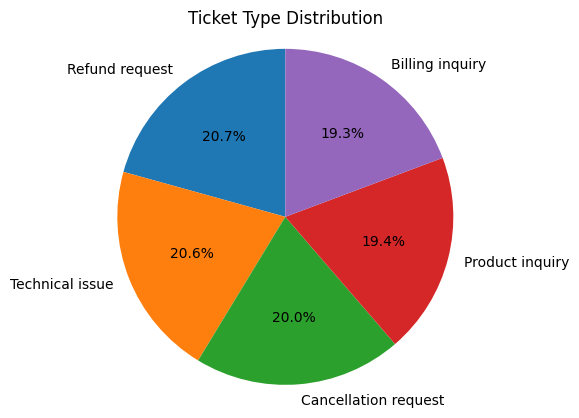

In [8]:
import matplotlib.pyplot as plt

# Count occurrences of each ticket type
ticket_counts = df['Ticket Type'].value_counts()

plt.figure()
plt.pie(
    ticket_counts.values,
    labels=ticket_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Ticket Type Distribution")
plt.axis('equal')  # makes the pie chart a circle
plt.show()


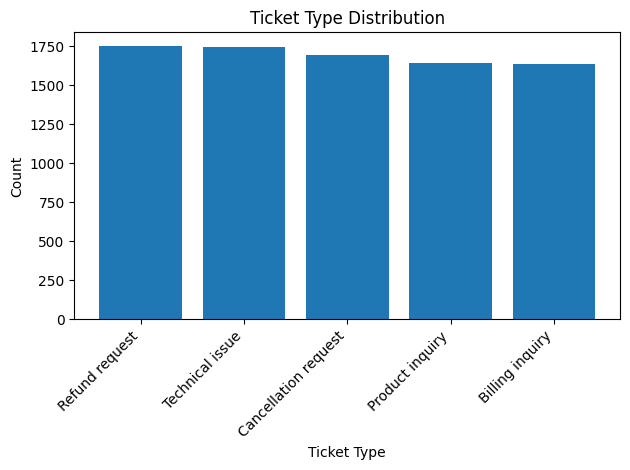

In [6]:
import matplotlib.pyplot as plt


ticket_counts = df['Ticket Type'].value_counts()

# Plot
plt.figure()
plt.bar(ticket_counts.index, ticket_counts.values)
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.title("Ticket Type Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


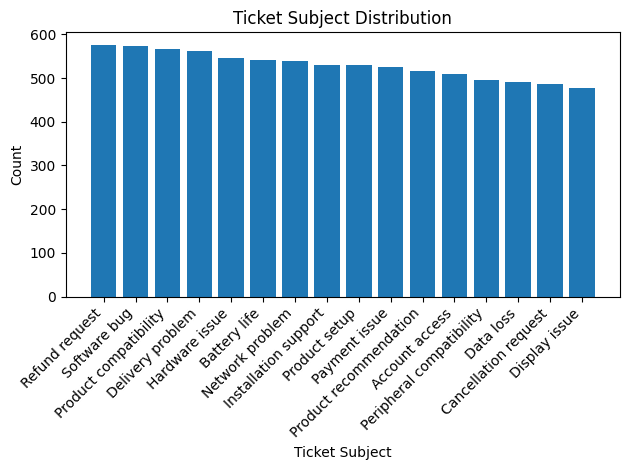

In [7]:
# pd.DataFrame(set(df['Ticket Subject']))
ticket_counts = df['Ticket Subject'].value_counts()

# Plot
plt.figure()
plt.bar(ticket_counts.index, ticket_counts.values)
plt.xlabel("Ticket Subject")
plt.ylabel("Count")
plt.title("Ticket Subject Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [17]:
for i in range(10):
    print(i)
    print(df['Ticket Description'][i])


0
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.
1
I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.
2
I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.
3
I'm having an issue with the {product_purchased}. Please assist.

If you have a problem you're interested in and I'd love to see this happen, please

# Data Cleaning

In [16]:
import re
SYSTEM_PHRASES = [
    "note:",
    "solution",
    "seller is not responsible",
    "please check out the feedback",
    "inventory",
    "suppliers",
    "request to",
    "shipped to you",
    "i will contact",
]

def remove_system_lines(text: str) -> str:
    text = text.lower()

    for phrase in SYSTEM_PHRASES:
        # remove from phrase until newline OR end of text
        pattern = rf"{re.escape(phrase)}.*?(?:\n|$)"
        text = re.sub(pattern, "", text, flags=re.IGNORECASE)

    return text.strip()


In [17]:
import re

def basic_clean(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\{.*?\}", "product", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


In [18]:
def remove_repetition(text: str) -> str:
    sentences = list(dict.fromkeys(text.split(".")))
    return ". ".join(sentences).strip()


In [19]:
def clean_ticket(text: str) -> str:
    text = basic_clean(text)
    text = remove_system_lines(text)
    text = remove_repetition(text)
    return text


In [ ]:
df["text"] = df["Ticket Subject"].fillna("") + " " + df["Ticket Description"].fillna("")
# 

In [86]:

df["text"] = df["text"].apply(clean_ticket)
df = df.drop_duplicates(subset=["text", "Ticket Type"])


In [87]:
df = df[["text", "Ticket Type"]].dropna()


In [59]:
df.head()

,text,Ticket Type
0,Product setup,Technical issue
1,Peripheral compatibility,Technical issue
2,Network problem,Technical issue
3,Account access,Billing inquiry
4,Data loss,Billing inquiry


In [88]:
label2id = {label: idx for idx, label in enumerate(df["Ticket Type"].unique())}
id2label = {v: k for k, v in label2id.items()}

In [89]:
df["label"] = df["Ticket Type"].map(label2id)


In [90]:
dataset = Dataset.from_pandas(df[["text", "label"]])
dataset = dataset.train_test_split(test_size=0.2)

# ______________________________________________________

# Fine Tunning BERT for Ticket Classification

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [92]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.remove_columns(["text"])
dataset.set_format("torch")


Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Map:   0%|          | 0/16 [00:00<?, ? examples/s]

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_ticket_router",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="epoch",
    report_to="none"
)



trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics
)



trainer.train()

AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [66]:
model.save_pretrained("tdm")
tokenizer.save_pretrained("tdm")


('tdm/tokenizer_config.json',
 'tdm/special_tokens_map.json',
 'tdm/vocab.txt',
 'tdm/added_tokens.json',
 'tdm/tokenizer.json')

In [1]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizerFast.from_pretrained("Bert_TDC")
model = DistilBertForSequenceClassification.from_pretrained("Bert_TDC")


2026-01-10 08:27:39.073000: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-10 08:27:39.086719: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-10 08:27:39.637573: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-10 08:27:42.707225: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [19]:
import torch

def predict_department( description,subject = '', threshold=0.65):
    text = subject.strip() + " " + description.strip()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    conf, pred_id = torch.max(probs, dim=1)

    confidence = conf.item()
    department = model.config.id2label[pred_id.item()]

    if confidence < threshold:
        action = "HUMAN_REVIEW"
    else:
        action = "AUTO_ROUTE"

    return {
        "department": department,
        "confidence": round(confidence, 3),
        "action": action
    }


In [3]:
predict_department(
    subject="Network problem",
    description="I'm facing a problem with my device to connect wifi"
)


{'department': 'Refund request', 'confidence': 0.44, 'action': 'HUMAN_REVIEW'}

In [ ]:
predict_department(
    description="My product is making strange noises and not functioning properly"
)


{'department': 'Technical issue',
 'confidence': 0.296,
 'action': 'HUMAN_REVIEW'}

# Custom Rule Based NER

In [4]:
import re


BRAND_KEYWORDS = {
    # Computing & Hardware
    "apple": ["apple", "iphone", "ipad", "macbook", "imac", "airpods"],
    "samsung": ["samsung", "galaxy", "exynos", "qled"],
    "dell": ["dell", "alienware", "inspiron", "vostro", "latitude", "xps"],
    "hp": ["hp", "hewlett packard", "pavilion", "envy", "spectre"],
    "lenovo": ["lenovo", "thinkpad", "ideapad", "yoga"],
    "asus": ["asus", "rog", "zenbook", "vivobook"],
    "acer": ["acer", "predator", "aspire", "swift"],
    "msi": ["msi", "stealth", "prestige"],
    "microsoft": ["microsoft", "windows", "surface", "xbox", "azure"],
    "google": ["google", "pixel", "chromebook", "nest", "android"],
    
    # Components
    "intel": ["intel", "core i7", "core i5", "xeon"],
    "amd": ["amd", "ryzen", "radeon"],
    "nvidia": ["nvidia", "geforce", "rtx", "gtx"],
    "gigabyte": ["gigabyte", "aorus"],
    
    # Peripherals & Audio
    "logitech": ["logitech", "logi"],
    "razer": ["razer", "blade", "blackwidow"],
    "corsair": ["corsair", "vengeance"],
    "bose": ["bose", "quietcomfort"],
    "sennheiser": ["sennheiser", "momentum"],
    "sony": ["sony", "playstation", "bravia", "xperia"],
    "lg": ["lg", "thinq", "ultragear"],
    
    # Networking
    "cisco": ["cisco", "meraki"],
    "netgear": ["netgear", "nighthawk"],
    "tp-link": ["tp-link", "deco"],
    "linksys": ["linksys", "velop"],
    "ubiquiti": ["ubiquiti", "unifi"],

    # Mobile & Other Electronics
    "xiaomi": ["xiaomi", "redmi", "mi", "poco"],
    "huawei": ["huawei", "matebook"],
    "oneplus": ["oneplus", "nord"],
    "motorola": ["motorola", "moto"],
    "nokia": ["nokia", "lumia"],
    "panasonic": ["panasonic", "toughbook"],
    "toshiba": ["toshiba", "dynabook"],
    "fujitsu": ["fujitsu"],
    "sharp": ["sharp", "aquos"],
    "canon": ["canon", "pixma", "eos"],
    "nikon": ["nikon", "coolpix"],
    "brother": ["brother"],
    "epson": ["epson", "ecotank"],
    "garmin": ["garmin", "fenix"],
    "fitbit": ["fitbit", "versa"],
    
    # Storage
    "western_digital": ["wd", "western digital", "my passport"],
    "seagate": ["seagate", "barracuda"],
    "kingston": ["kingston", "hyperx"],
    "sandisk": ["sandisk", "extreme"],
    
    # Software & Services
    "adobe": ["adobe", "photoshop", "illustrator", "acrobat"],
    "slack": ["slack"],
    "zoom": ["zoom"],
    "oracle": ["oracle"],
    "amazon": ["amazon", "aws", "kindle", "echo"]
}

PRODUCT_KEYWORDS = {
    # Devices
    "phone": ["phone", "mobile", "smartphone", "handset", "cellphone"],
    "laptop": ["laptop", "notebook", "ultrabook"],
    "desktop": ["desktop", "pc", "workstation", "tower"],
    "tablet": ["tablet", "tab", "ipad"],
    "monitor": ["monitor", "screen", "display"],
    "printer": ["printer", "copier", "inkjet", "laserjet"],
    "scanner": ["scanner"],
    "camera": ["camera", "webcam", "dslr"],
    
    # Networking
    "router": ["router", "modem", "gateway", "access point"],
    "wifi": ["wifi", "wi-fi", "internet", "connectivity", "broadband"],
    "switch": ["switch", "hub", "ethernet"],
    
    # Accessories
    "keyboard": ["keyboard"],
    "mouse": ["mouse", "trackpad"],
    "headset": ["headset", "headphones", "earphones", "earbuds"],
    "speaker": ["speaker", "audio", "soundbar"],
    "watch": ["watch", "smartwatch", "wearable"],
    
    # Internal Components
    "processor": ["processor", "cpu", "chip"],
    "graphics": ["graphics card", "gpu", "video card"],
    "ram": ["ram", "memory"],
    "storage": ["ssd", "hdd", "hard drive", "drive"],
    "motherboard": ["motherboard", "mainboard"],
    "battery": ["battery", "power pack"],
    "charger": ["charger", "adapter", "power supply", "psu"],
    "cable": ["cable", "hdmi", "usb", "thunderbolt"],
    
    # Software & Virtual
    "app": ["app", "application", "mobile app"],
    "software": ["software", "program", "tool", "suite"],
    "os": ["operating system", "windows", "macos", "linux", "ios", "android"],
    "firmware": ["firmware", "bios"],
    "driver": ["driver", "update"],
    "browser": ["browser", "chrome", "firefox", "safari", "edge"],
    "firewall": ["firewall", "security"],
    "antivirus": ["antivirus", "malware"],
    
    # Account & Billing
    "account": ["account", "profile", "login", "id"],
    "password": ["password", "credential", "reset"],
    "subscription": ["subscription", "membership", "plan"],
    "invoice": ["invoice", "bill", "receipt", "payment"],
    "refund": ["refund", "money back", "reimbursement"],
    "warranty": ["warranty", "guarantee", "protection plan"],
    "license": ["license", "product key", "activation"],
    "portal": ["portal", "dashboard", "website", "site"],
    "cloud": ["cloud", "storage", "drive", "backup"]
}



In [5]:

# ---------- NER Function ----------

def extract_entities(ticket_text: str) -> dict:
    """
    Extract brands, product type, and issue types from raw support text.
    """

    # Normalize text
    text = ticket_text.lower()
    text = re.sub(r"\{.*?\}", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    # --- Brand extraction ---
    brands = set()
    for brand, keywords in BRAND_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                brands.add(brand)
                break

    if not brands:
        brands = {"unknown"}

    # --- Product extraction ---
    product = "unknown"
    for prod, keywords in PRODUCT_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                product = prod
                break
        if product != "unknown":
            break


    return {"brands": list(brands), "product": product    }


# Fine-Tuning BERT for Sentiment Analysis 

In [6]:
def analyze_sentiment(ticket_text):

    text = ticket_text[:512]

    result = sentiment_model(text)[0]

    label = result["label"]      
    score = result["score"]      

    # Convert sentiment to urgency
    if label == "NEGATIVE" and score >= 0.75:
        priority = "HIGH"
    elif label == "NEGATIVE":
        priority = "MEDIUM"
    else:
        priority = "LOW"

    return {
        "sentiment": label,
        "confidence": round(score, 3),
        "priority": priority
    }
 

In [1]:
from datasets import load_dataset

dataset = load_dataset("go_emotions")


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [7]:
EMOTION_MAP = {
    "anger": 0,
    "sadness": 1,
    "joy": 2,
    "neutral": 3
}


In [8]:
ID2EM = {
    0: "anger",
    1: "sadness",
    2: "joy",
    3: "neutral"
}

In [3]:
emotion_names = dataset["train"].features["labels"].feature.names


In [4]:
def map_emotion(example):
    for idx in example["labels"]:
        emotion = emotion_names[idx]
        if emotion in EMOTION_MAP:
            example["label"] = EMOTION_MAP[emotion]
            return example

    # fallback
    example["label"] = EMOTION_MAP["neutral"]
    return example


In [5]:
dataset = dataset.map(map_emotion)
dataset = dataset.remove_columns(["labels"])


Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [6]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [7]:
dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)


In [8]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)


2026-01-09 16:02:44.049268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767974564.364464      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767974564.459809      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767974565.317506      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767974565.317551      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767974565.317554      55 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./emotion_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=6,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    report_to="none"
)



In [11]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }


In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.241800,0.244679,0.916513,0.914471
2,0.225400,0.248011,0.918909,0.914559
3,0.147600,0.313908,0.918172,0.913384
4,0.123000,0.398399,0.911168,0.909651
5,0.055800,0.490479,0.912459,0.909436
6,0.031200,0.536180,0.910431,0.908017


TrainOutput(global_step=16284, training_loss=0.14003080374132765, metrics={'train_runtime': 1614.2408, 'train_samples_per_second': 161.351, 'train_steps_per_second': 10.088, 'total_flos': 8625922314670080.0, 'train_loss': 0.14003080374132765, 'epoch': 6.0})

In [13]:
model.save_pretrained("emotion_bert")
tokenizer.save_pretrained("emotion_bert")


('emotion_bert/tokenizer_config.json',
 'emotion_bert/special_tokens_map.json',
 'emotion_bert/vocab.txt',
 'emotion_bert/added_tokens.json',
 'emotion_bert/tokenizer.json')

In [9]:
sent_tokenizer = DistilBertTokenizerFast.from_pretrained("sentimentmodel")
sent_model = DistilBertForSequenceClassification.from_pretrained("sentimentmodel")

In [10]:
def predict_emotion(text):
    """
    Predict emotion: anger / sadness / joy / neutral
    """

    inputs = tokenizer(
        text.strip()[:512],
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = sent_model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

    pred_id = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_id].item()
    label = ID2EM[pred_id]

    if label == "anger" and confidence >= 0.75:
        priority = "HIGH"
    elif label == "negative":
        priority = "MEDIUM"
    else:
        priority = "LOW"

    return {
        'priority': priority,
        "emotion": label,
        "confidence": round(confidence, 3)
    }




In [23]:
predict_emotion('this is very frustrating and very bad')

{'priority': 'HIGH', 'emotion': 'anger', 'confidence': 0.996}

In [ ]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_ticket(new_description, file_path="processed_tickets.csv", sim_threshold=0.85):
    if not os.path.exists(file_path) or os.stat(file_path).st_size == 0:
        return None

    #  Load the saved tickets
    history_df = pd.read_csv(file_path)
    
    vectorizer = TfidfVectorizer(stop_words='english')
    
    tfidf_matrix = vectorizer.fit_transform(history_df['description'])
    
    new_vec = vectorizer.transform([new_description])

    scores = cosine_similarity(new_vec, tfidf_matrix).flatten()
    
    #  Pick the best match
    best_idx = scores.argmax()
    highest_score = scores[best_idx]

    # Return the match if it's "close enough"
    if highest_score >= sim_threshold:
        print(f"--- [CACHE HIT] Match Found ({highest_score:.2f}) ---")
        return history_df.iloc[[best_idx]]

    return None



# Final PipeLine


In [37]:
def nlp_pipeline(description, threshold=0.65, sim_threshold=0.65):

    cached_result = find_similar_ticket(description, sim_threshold=sim_threshold)
    if cached_result is not None:
        print(cached_result)

    print("--- [CACHE MISS] Running BERT Models... ---")
    
    # Classification
    routing_result = predict_department(description=description, threshold=threshold)
    
    # NER
    entity_result = extract_entities(description)
    
    # Sentiment
    sentiment_result = predict_emotion(description)

    new_data = pd.DataFrame({
        "description": [description],
        "department": [routing_result["department"]],
        "routing_confidence": [routing_result["confidence"]],
        "action": [routing_result["action"]],
        "brands": [", ".join(entity_result.get("brands", []))],
        "product": [entity_result.get("product", "unknown")],
        "sentiment": [sentiment_result["emotion"]],
        "sentiment_confidence": [sentiment_result["confidence"]],
        "priority": [sentiment_result["priority"]]
    })

    # Save for future searches
    file_path = "processed_tickets.csv"
    new_data.to_csv(file_path, mode='a', index=False, header=not os.path.exists(file_path))

    return new_data

In [39]:
result = nlp_pipeline(
    description="My Samsung Galaxy phone is not charging and draining very fast its only been 10 days since i bought it is very frustrating."
)

result.head()


--- [CACHE HIT] Similarity: 0.75 ---
                                         description       department  \
2  My Samsung Galaxy phone is not charging its on...  Technical issue   

   routing_confidence        action   brands product sentiment  \
2               0.586  HUMAN_REVIEW  samsung   phone     anger   

   sentiment_confidence priority timestamp  
2                 0.996     HIGH       NaN  
--- [CACHE MISS] Running BERT Models... ---


,description,department,routing_confidence,action,brands,product,sentiment,sentiment_confidence,priority
0,My Samsung Galaxy phone is not charging and dr...,Technical issue,0.384,HUMAN_REVIEW,samsung,phone,anger,0.996,HIGH
